In [1]:
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig
import numpy as np
import pandas as pd
from scipy.special import softmax

In [35]:
import torch
from sklearn import preprocessing

In [ ]:
pipe = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
pipe("it's too bad to hear this!")

[{'label': 'negative', 'score': 0.9431511759757996}]

In [2]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
# PT
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
text = "it's too bad to hear this!"
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
# Print labels and scores
ranking = np.argsort(scores)
ranking = ranking[::-1]
for i in range(scores.shape[0]):
    l = config.id2label[ranking[i]]
    s = scores[ranking[i]]
    print(f"{i+1}) {l} {np.round(float(s), 4)}")


1) negative 0.9432
2) neutral 0.0499
3) positive 0.007


In [ ]:
scores

array([0.9431512 , 0.04987143, 0.00697744], dtype=float32)

In [ ]:
ranking

array([0, 1, 2])

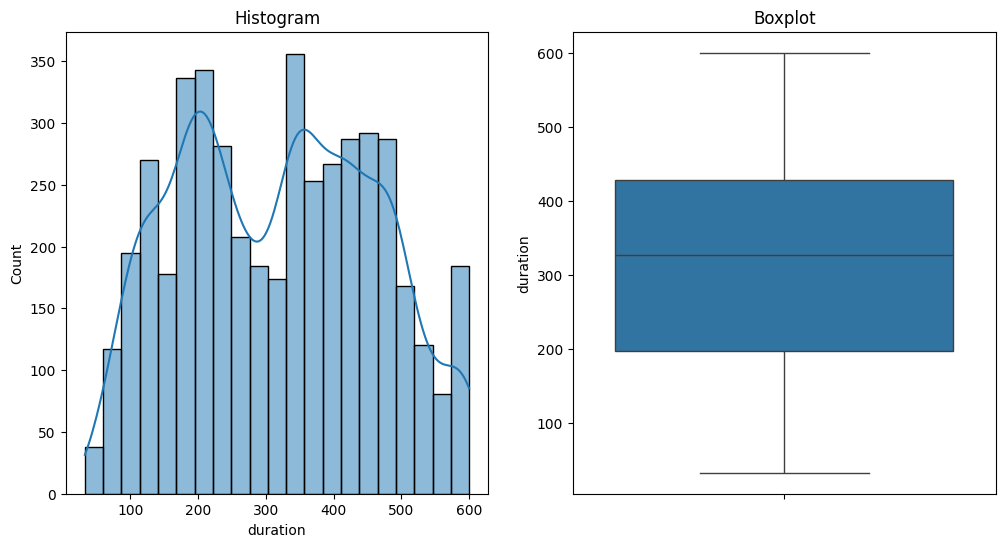

The data follows a Gaussian distribution and does not contain outliers.
Recommendation: Use standardization (z-score normalization).


In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def choose_scaling_method(df, column):
    # Extract the specified column
    data = df[column]

    # Calculate mean, median, standard deviation, minimum, and maximum
    mean = np.mean(data)
    median = np.median(data)
    std_dev = np.std(data)
    min_value = np.min(data)
    max_value = np.max(data)

    # Plot histogram and boxplot to visualize the distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    sns.histplot(data, kde=True, ax=axes[0])
    sns.boxplot(data, ax=axes[1])
    axes[0].set_title('Histogram')
    axes[1].set_title('Boxplot')
    plt.show()

    # Check if the data follows a Gaussian distribution
    is_gaussian = (np.abs(mean - median) < 2 * std_dev) and (min_value > mean - 3 * std_dev) and (max_value < mean + 3 * std_dev)

    # Check the presence of outliers
    has_outliers = (np.abs(data - mean) > 2 * std_dev).any()

    # Determine recommendation based on distribution and presence of outliers
    if is_gaussian and not has_outliers:
        print("The data follows a Gaussian distribution and does not contain outliers.")
        print("Recommendation: Use standardization (z-score normalization).")
    else:
        print("The data does not follow a Gaussian distribution and/or contains outliers.")
        print("Recommendation: Use normalization (scaling to a specific range).")

# Example usage
# Assuming df is your DataFrame and 'column_name' is the name of the column to analyze
choose_scaling_method(chat_data, 'duration') #duration - std


In [34]:
chat_data.describe()

,batch_num,team_size,score,duration,efficiency,num_words,num_chars,num_messages
count,4619.000000,4619.000000,4619.000000,4619.00000,4619.000000,4619.000000,4619.000000,4619.0
mean,2.392942,5.579346,698.950206,317.77073,2.872013,4.437108,20.136393,1.0
std,1.650479,2.760690,148.595935,143.75540,1.855090,4.133399,20.126893,0.0
min,1.000000,1.000000,340.000000,33.00000,0.583333,0.000000,0.000000,1.0
25%,1.000000,3.000000,583.000000,198.00000,1.596939,1.000000,4.000000,1.0
50%,1.000000,6.000000,652.000000,327.00000,2.239884,3.000000,14.000000,1.0
75%,4.000000,8.000000,844.000000,428.00000,3.570588,6.000000,27.000000,1.0
max,5.000000,10.000000,986.000000,600.00000,15.285714,35.000000,161.000000,1.0


In [110]:
class sentiment_model:
    def __init__(self, model_path="cardiffnlp/twitter-roberta-base-sentiment-latest"):
        self.model = CustomRoBERTaForSequenceClassification.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.config = AutoConfig.from_pretrained(model_path)
        self.pipeline = pipeline('sentiment-analysis', model=self.model, tokenizer=self.tokenizer, config=self.config)

    def encode_input(self, text):
        return self.tokenizer(text, return_tensors='pt')

    def get_score(self, text, efficiency, duration, score):
        encoded_input = self.encode_input(text)
        # print(encoded_input)
        # numerical_features = [efficiency, duration, score]
        # numerical_tensor = torch.tensor(numerical_features, dtype=torch.float)
        # encoded_input['team'] = numerical_tensor.unsqueeze(0)
        output = self.model(**encoded_input)
        scores = output[0][0].detach().numpy()
        scores = softmax(scores)
        ranking = np.argsort(scores)
        ranking = ranking[::-1]
        result = {}
        for i in range(scores.shape[0]):
            l = self.config.id2label[ranking[i]]
            s = scores[ranking[i]]
            result[l] = s
            print(f"{i+1}) {l} {np.round(float(s), 4)}")
        # features = self.engineer_features(efficiency, duration, score)
        features = [efficiency, duration, score]
        adjusted_result = self.adjust_sentiment(result, features)
        print(result)
        print(adjusted_result)
        return result, adjusted_result

    def engineer_features(self, efficiency, duration, score):
        # Initialize scaler for normalization and standardization
        min_max_scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
        standard_scaler = preprocessing.StandardScaler()

        # Normalize efficiency and score, standardize duration

        print(normalized_efficiency)
        return {
            'normalized_efficiency': normalized_efficiency[0],
            'standardized_duration': standardized_duration[0],
            'normalized_score': normalized_score[0]
        }

    def adjust_sentiment(self, result, features):
        # Example adjustment based on feature values
        adjusted_scores = result.copy()
        print(features)
        # Adjust sentiment scores based on feature values
        if features[0] < 0 and features[1] > 0 and features[2] < 0:
            print('bad!!!!!!')
            adjusted_scores['negative'] *= 1.2
            adjusted_scores['positive'] *= 0.8
        elif features[0] > 0 and features[1] < 0 and features[2] > 0:
            print('good!!!!!!')
            adjusted_scores['negative'] *= 0.8
            adjusted_scores['positive'] *= 1.2
        return adjusted_scores

# TODO - DEFINE YOUR FEATURE EXTRACTOR HERE
def get_sentiment(model0, text, efficiency, duration, score):
    print(type(text), text)
    return model0.get_score(text, efficiency, duration, score)
    # sample output format
    # return({'positive': 0.0, 'negative': 0.0, 'neutral': 0.0})

In [111]:
model0 = sentiment_model(model_path="cardiffnlp/twitter-roberta-base-sentiment-latest")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [140]:
chat_data = pd.read_csv("/content/drive/MyDrive/Penn/CSSLab/tpm_ml_test/feature_engine/output/csopII_label_chat_level_100.csv")
chat_data = chat_data.dropna()
chat_data = chat_data.reset_index()
min_max_scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
standard_scaler = preprocessing.StandardScaler()
features = ['efficiency', 'score', 'duration']
df_scaled = standard_scaler.fit_transform(chat_data[features])
# chat_data = min_max_scaler.fit_transform(chat_data['score'])
df_scaled_0 = pd.DataFrame(df_scaled, columns=features)
df_combined = pd.concat([chat_data.drop(columns=features), df_scaled_0], axis=1)


In [141]:
df_combined

,index,conversation_num,batch_num,vis_img,int_verb,ort_img,rep_man,soc_pers,team_size,difficulty,...,message,timestamp,message_lower_with_punc,num_words,num_chars,num_messages,sentiment,efficiency,score,duration
0,0,rHPaiuXkM3Ss4rEsW,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,can we get d to the highest score,2021-02-26T19:11:21.474Z,can we get d to the highest score?,8,33,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",3.599350,0.593709,-1.894491
1,1,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,looks good,2021-02-26T19:22:32.695Z,looks good,2,10,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045
2,2,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,i like it,2021-02-26T19:23:14.467Z,i like it,3,9,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045
3,3,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,it looks good to me,2021-02-26T19:23:20.650Z,it looks good to me,5,19,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045
4,4,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,stop changing it,2021-02-26T19:23:52.111Z,stop changing it,3,16,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,95,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,my mistake 105,2021-03-10T18:11:03.026Z,"my mistake, 105",3,14,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734
78,96,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,b shoul dbe in 101,2021-03-10T18:12:06.518Z,b shoul dbe in 101,5,18,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734
79,97,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,a shpuld be in 102,2021-03-10T18:12:20.806Z,a shpuld be in 102,5,18,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734
80,98,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,c d in 103 maximizes,2021-03-10T18:13:02.289Z,c & d in 103 maximizes,5,21,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

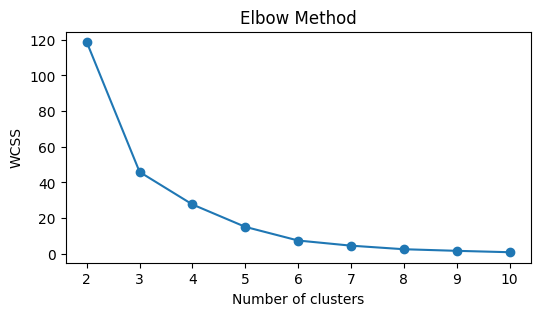

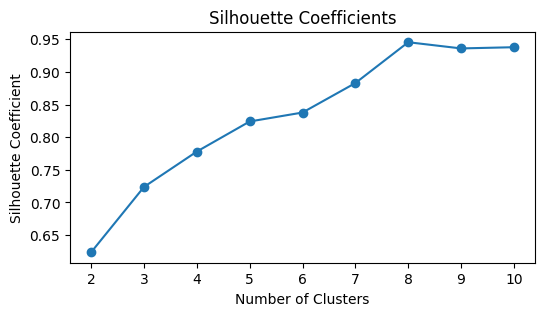

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [142]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Sample DataFrame creation (replace this with your actual DataFrame)
# df = pd.DataFrame({
#     'chat_message': [...],  # Your chat messages
#     'sentiment_score': [...],  # Sentiment scores
#     'efficiency': [...],
#     'duration': [...],
#     'score': [...]
# })

# Assuming 'sentiment_score', 'efficiency', 'duration', 'score' are already in df
# df = chat_data
# # Feature Engineering: Standardize the features
# features = ['sentiment_score', 'efficiency', 'duration', 'score']
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df[features])

# Finding the optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
silhouette_coefficients = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

# Plotting the Elbow Method
plt.figure(figsize=(6, 3))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Plot Silhouette Coefficients
plt.figure(figsize=(6, 3))
plt.plot(range(2, 11), silhouette_coefficients, marker='o')
plt.title('Silhouette Coefficients')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

# Choose the number of clusters (k) based on the plots and apply KMeans clustering
k = 4  # Example choice, adjust based on your Elbow and Silhouette analysis
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
df_combined['cluster'] = kmeans.fit_predict(df_scaled)

# Now df has a new column 'cluster' indicating the cluster each record belongs to


In [143]:
cluster_characteristics = df_combined.groupby('cluster')[features].mean()
print(cluster_characteristics)


         efficiency     score  duration
cluster                                
0          0.217041 -0.993089 -0.770757
1         -0.775348  1.614634  1.756830
2          2.997624  1.391469 -1.689445
3         -0.563599  0.367622  0.655522


In [144]:
df_combined

,index,conversation_num,batch_num,vis_img,int_verb,ort_img,rep_man,soc_pers,team_size,difficulty,...,timestamp,message_lower_with_punc,num_words,num_chars,num_messages,sentiment,efficiency,score,duration,cluster
0,0,rHPaiuXkM3Ss4rEsW,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,2021-02-26T19:11:21.474Z,can we get d to the highest score?,8,33,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",3.599350,0.593709,-1.894491,2
1,1,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,2021-02-26T19:22:32.695Z,looks good,2,10,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045,3
2,2,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,2021-02-26T19:23:14.467Z,i like it,3,9,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045,3
3,3,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,2021-02-26T19:23:20.650Z,it looks good to me,5,19,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045,3
4,4,dArSAcrzmb9bR6Pug,1,High,High,High,High,High,5,Easy [Corresponds to 'Hard' in PNAS],...,2021-02-26T19:23:52.111Z,stop changing it,3,16,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.601608,0.113273,0.660045,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,95,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,2021-03-10T18:11:03.026Z,"my mistake, 105",3,14,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734,1
78,96,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,2021-03-10T18:12:06.518Z,b shoul dbe in 101,5,18,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734,1
79,97,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,2021-03-10T18:12:20.806Z,a shpuld be in 102,5,18,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734,1
80,98,kySX6MHndg67cD3Li,1,Low,Mixed,Low,Mixed,High,7,Easy [Corresponds to 'Hard' in PNAS],...,2021-03-10T18:13:02.289Z,c & d in 103 maximizes,5,21,1,"{'positive': 0.0, 'negative': 0.0, 'neutral': ...",-0.747687,1.696931,1.676734,1


In [105]:
df_head = df_combined.head(5)

In [112]:
df_head.apply(
        lambda row: get_sentiment(
            model0,
            row["message_lower_with_punc"],
            row["efficiency"],
            row["duration"],
            row["score"]
        ),
        axis=1
    )

<class 'str'> can we get d to the highest score?
1) neutral 0.7151
2) positive 0.2755
3) negative 0.0094
[3.599349519133791, -1.8944913889567128, 0.5937088432252254]
good!!!!!!
{'neutral': 0.71505904, 'positive': 0.27554277, 'negative': 0.009398274}
{'neutral': 0.71505904, 'positive': 0.330651319026947, 'negative': 0.0075186192989349365}
<class 'str'> looks good
1) positive 0.8554
2) neutral 0.1299
3) negative 0.0147
[-0.6016078317044852, 0.6600452592553909, 0.11327339772060234]
{'positive': 0.8554173, 'neutral': 0.12992789, 'negative': 0.014654785}
{'positive': 0.8554173, 'neutral': 0.12992789, 'negative': 0.014654785}
<class 'str'> i like it
1) positive 0.7193
2) neutral 0.2511
3) negative 0.0296
[-0.6016078317044852, 0.6600452592553909, 0.11327339772060234]
{'positive': 0.7193485, 'neutral': 0.2510961, 'negative': 0.02955547}
{'positive': 0.7193485, 'neutral': 0.2510961, 'negative': 0.02955547}
<class 'str'> it looks good to me
1) positive 0.9463
2) neutral 0.0488
3) negative 0.0048

0    ({'neutral': 0.71505904, 'positive': 0.2755427...
1    ({'positive': 0.8554173, 'neutral': 0.12992789...
2    ({'positive': 0.7193485, 'neutral': 0.2510961,...
3    ({'positive': 0.94632715, 'neutral': 0.0488344...
4    ({'negative': 0.67622167, 'neutral': 0.3048358...
dtype: object